In [ ]:
from datascience import *
path_data = 'https://raw.githubusercontent.com/data-8/textbook/main/assets/data/'
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np

# Table Reading


1. Each of the 354,152 rows corresponds to a biking trip, while the columns represent the duration of the trips in seconds and providing information like the start date, start station, start terminal, end date, end station, end terminal, bike number, subscriber type, and the zip code.

In [ ]:
trips = Table.read_table(path_data + 'trip.csv')
trips

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107
913454,409,8/31/2015 23:10,San Jose City Hall,10,8/31/2015 23:17,San Salvador at 1st,8,68,Subscriber,95113
913453,789,8/31/2015 23:09,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,487,Customer,9069
913452,293,8/31/2015 23:07,Yerba Buena Center of the Arts (3rd @ Howard),68,8/31/2015 23:12,San Francisco Caltrain (Townsend at 4th),70,538,Subscriber,94118
913451,896,8/31/2015 23:07,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,363,Customer,92562
913450,255,8/31/2015 22:16,Embarcadero at Sansome,60,8/31/2015 22:20,Steuart at Market,74,470,Subscriber,94111
913449,126,8/31/2015 22:12,Beale at Market,56,8/31/2015 22:15,Temporary Transbay Terminal (Howard at Beale),55,439,Subscriber,94130
913448,932,8/31/2015 21:57,Post at Kearny,47,8/31/2015 22:12,South Van Ness at Market,66,472,Subscriber,94702


# Minimum & Maximum Values

2. The shortest bike trip recorded took 60 seconds and the longest was 17,270,400 seconds long. The rest of the trips were mostly between 200 and 1000 seconds long.

In [ ]:
trips.column('Duration').min()

60

In [ ]:
trips.column('Duration').max()

17270400

# Duration

3. The following histogram below shows the duration data from the trips:

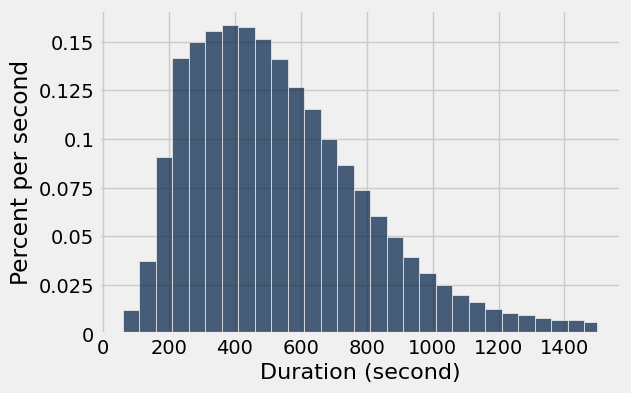

In [ ]:
delay_bins = np.append(np.arange(60, 1500, 50), 1500)
trips.hist('Duration', bins = delay_bins, unit = 'second')

4. The previous histogram was just a part taken from the whole graph that contained the most amount of trips. The excluded trips on graph exceeded 1,500 seconds in length and only made up 5.7% of all trips, so the graph still properly displays the important data.

In [ ]:
trips.where('Duration', are.above(1500)).num_rows/trips.num_rows

0.05709977636720956

# Mean & Median

5. The median is expected to be smaller than the mean, which will reaffirm the distribution.

In [ ]:
np.median(trips.column('Duration'))

511.0

In [ ]:
np.mean(trips.column('Duration'))

1046.0326611172604

6. With 5,000 samples of size 100 we're able to simulate the median duration in a histogram.

In [ ]:
def empirical_hist_delay(n):
    trips.sample(n).hist('Duration', bins = delay_bins, unit = 'second')

In [ ]:
np.median(trips.sample(5000).column('Duration'))

510.0

In [ ]:
def random_sample_median():
    return np.median(trips.sample(100).column('Duration'))

In [ ]:
medians = make_array()

for i in np.arange(5000):
    medians = np.append(medians, random_sample_median())

In [ ]:
simulated_medians = Table().with_column('Sample Median', medians)
simulated_medians

Sample Median
501.5
498
468
456.5
521.5
450.5
552.5
527.5
536
537.5


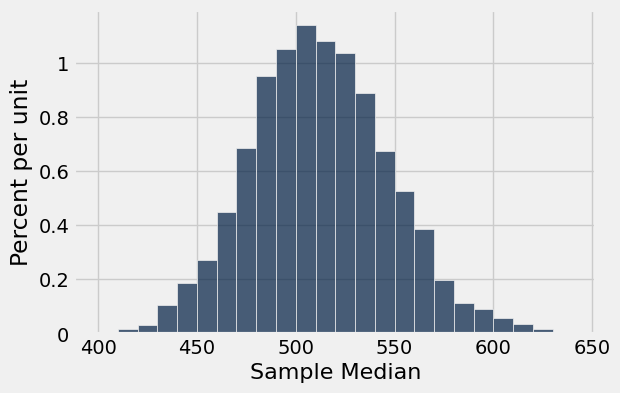

In [ ]:
simulated_medians.hist(bins=np.arange(400, 650, 10))

7. Next we can simulate the median duration again, this time with 5,000 samples of size 400 in a histogram.

In [ ]:
def random_sample_median():
    return np.median(trips.sample(400).column('Duration'))

In [ ]:
medians = make_array()

for i in np.arange(5000):
    medians = np.append(medians, random_sample_median())

In [ ]:
simulated_medians = Table().with_column('Sample Median', medians)
simulated_medians

Sample Median
521
523.5
522.5
505
515
507
505.5
518.5
500.5
520.5


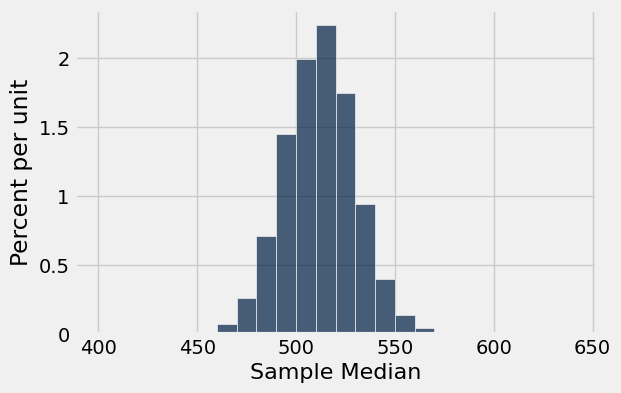

In [ ]:
simulated_medians.hist(bins=np.arange(400, 650, 10))

8. The histograph demonstrates that the medians will appear to be closer together the higher the sample size used. As the sample size increases, the median of the population will be represented with increasingly better accuracy along with a narrower distribution.